Maxwell-Bloch Equations

In [1]:
using DifferentialEquations
using Plots

In [9]:
function sigmaz_exp!(du, u, p, t)
    ρ_ee, ρ_ge, ρ_eg, ρ_gg = u
    Γ , Ω, Δ = p

    du[1] = -(Γ * ρ_ee - im * (Ω) * (ρ_ge - ρ_eg))           # dρ_gg
    du[2] = (im * Δ - Γ/2) * ρ_ge + im * (Ω) * (ρ_ee - ρ_gg)      # dρ_ge
    du[3] = -du[2]                                          # dρ_eg
    du[4] = -du[1]                                          # dρ_ee
end

sigmaz_exp! (generic function with 1 method)

In [14]:
u0 = [0.0, 0.0 + 0.0im, 0.0 + 0.0im, 1.0]  # Initial conditions
saveat = tf / (nT - 1)

prob = ODEProblem(sigmaz_exp!, u0, tspan, saveat=saveat, p)
sol = solve(prob, Tsit5());

ErrorException: The length of tspan must be two (and preferably, tspan should be a tuple, i.e. (0.0,1.0)). If you are trying to include other values for saving reasons, see the [common solver arguments page](https://docs.sciml.ai/DiffEqDocs/stable/basics/common_solver_opts/) for information on the saving command saveat.

In [11]:
# Extract real parts
t = sol.t * Γ
ρ_ee_real = real(sol[1, :])
ρ_gg_real = real(sol[4, :])

sigma_z = ρ_ee_real - ρ_gg_real;


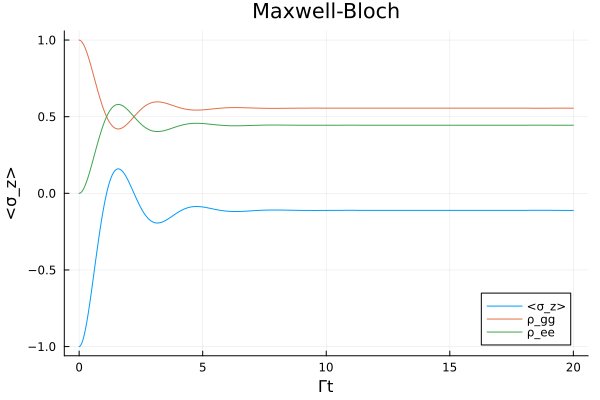

In [12]:
# Plot real parts
plot(t, sigma_z, label = "<σ_z>", xlabel = "Γt", ylabel = "<σ_z>", title = "Maxwell-Bloch")
plot!(t, ρ_gg_real, label = "ρ_gg")
plot!(t, ρ_ee_real, label = "ρ_ee")